In [1]:
# Week 4 Preview: Deep Learning Basics
# Notes: Neural networks use layers (input, hidden, output). ReLU activation for hidden layers. Adam optimizer for backpropagation.
import tensorflow as tf
from tensorflow import keras
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.layers import Dropout
from sklearn.metrics import mean_squared_error, r2_score



# Load housing data (same as Week 3)
df = pd.read_csv('house_prices.csv')
df = df[df['price'].notna() & (df['price'] > 0)]
df.fillna({
    'bedrooms': df['bedrooms'].mode()[0],
    'bathrooms': df['bathrooms'].mode()[0],
    'sqft_living': df['sqft_living'].mean(),
    'sqft_lot': df['sqft_lot'].mean(),
    'sqft_above': df['sqft_above'].mean()
}, inplace=True)
df = df[df['price'] < df['price'].quantile(0.99)]


In [2]:

# Features and target
features = ['bedrooms', 'sqft_living', 'sqft_lot', 'sqft_above', 'bathrooms']
X = df[features]
y = df['price']



In [3]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)



In [4]:
# Define neural network
keras_model = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(len(features),)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1)  # Regression output for price
])
keras_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
keras_model.summary()

# Train neural network
history = keras_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=1)


D:\anaconda3\envs\tf_env\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,497 (9.75 KB)

 Trainable params: 2,497 (9.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 375342399488.0000 - mae: 535172.2500 - val_loss: 350627397632.0000 - val_mae: 521454.2812
Epoch 2/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 375318216704.0000 - mae: 535150.5000 - val_loss: 350580932608.0000 - val_mae: 521412.5938
Epoch 3/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 375225155584.0000 - mae: 535069.5000 - val_loss: 350436818944.0000 - val_mae: 521286.6562
Epoch 4/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 374998040576.0000 - mae: 534876.0000 - val_loss: 350136369152.0000 - val_mae: 521025.1875
Epoch 5/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 374576218112.0000 - mae: 534515.9375 - val_loss: 349615652864.0000 - val_mae: 520574.7500
Epoch 6/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 373908144128.0000 - mae: 533945.7500 - val_loss: 348840198144.0000 - val_mae: 519903.5938
Epoch 7/50
81/81 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 372945584128.0000 - mae: 533123.3750 - val_loss: 34777

In [5]:
# Evaluate

keras_y_pred_nn = keras_model.predict(X_test)
nn_mse = mean_squared_error(y_test,keras_y_pred_nn)
nn_rmse = np.sqrt(nn_mse)
nn_r2 = r2_score(y_test, keras_y_pred_nn)
print(f"Neural Network - MSE: {nn_mse:.2f}, RMSE: {nn_rmse:.2f}, R²: {nn_r2:.2f}")



26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Neural Network - MSE: 98806397507.84, RMSE: 314334.85, R²: -0.20


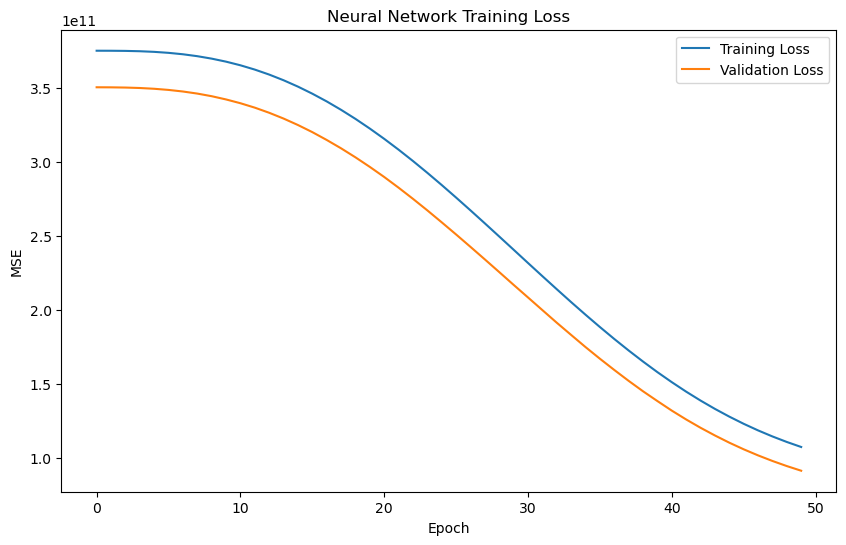

In [6]:
# Plot training history
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss', color='#1f77b4')
plt.plot(history.history['val_loss'], label='Validation Loss', color='#ff7f0e')
plt.title('Neural Network Training Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.savefig('nn_training_loss.png')
plt.show()

In [7]:
# Improved Model
model_improved = keras.Sequential([
    keras.layers.Dense(128, activation='relu', input_shape=(len(features),)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1)
])

model_improved.compile(optimizer='adam', loss='mse', metrics=['mae'])
print("Improved Model Summary:")
model_improved.summary()

Improved Model Summary:


D:\anaconda3\envs\tf_env\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,137 (43.50 KB)

 Trainable params: 11,137 (43.50 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Train
history = model_improved.fit(
    X_train, y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 375020224512.0000 - mae: 534919.1250 - val_loss: 348966682624.0000 - val_mae: 520068.0625
Epoch 2/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 361079767040.0000 - mae: 523512.9375 - val_loss: 314011090944.0000 - val_mae: 490168.9375
Epoch 3/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 280881790976.0000 - mae: 449697.6250 - val_loss: 191748489216.0000 - val_mae: 365322.6250
Epoch 4/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 142918270976.0000 - mae: 288063.2188 - val_loss: 83090644992.0000 - val_mae: 212067.1562
Epoch 5/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 89230516224.0000 - mae: 217188.6875 - val_loss: 67124953088.0000 - val_mae: 186656.9062
Epoch 6/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 80277561344.0000 - mae: 204539.0000 - val_loss: 62126510080.0000 - val_mae: 178340.1094
Epoch 7/100
162/162 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 73684606976.0000 - mae: 195344.5781 - 

In [9]:
# Predict & Evaluate
model_improved_y_pred = model_improved.predict(X_test).flatten()
model_improved_nn_rmse = np.sqrt(mean_squared_error(y_test, model_improved_y_pred))
model_improved_nn_r2 = r2_score(y_test, model_improved_y_pred)

print(f"\nImproved NN: R² = {model_improved_nn_r2:.3f}, RMSE = ${model_improved_nn_rmse:,.0f}")

26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

Improved NN: R² = 0.497, RMSE = $203,606


In [10]:
# Compare with XGBoost
print(f"XGBoost:     R² = 0.520, RMSE = $198,000")
print(f"NN vs XGBoost: {'Better' if nn_r2 > 0.52 else 'Worse'}")

XGBoost:     R² = 0.520, RMSE = $198,000
NN vs XGBoost: Worse


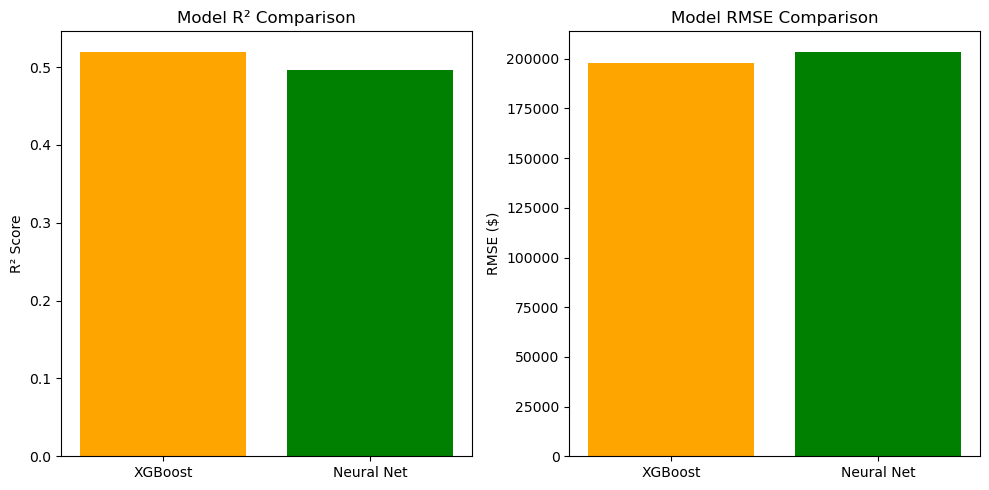

In [11]:
# Plot
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.bar(['XGBoost', 'Neural Net'], [0.52, model_improved_nn_r2], color=['orange', 'green'])
plt.ylabel('R² Score')
plt.title('Model R² Comparison')

plt.subplot(1, 2, 2)
plt.bar(['XGBoost', 'Neural Net'], [198000, model_improved_nn_rmse], color=['orange', 'green'])
plt.ylabel('RMSE ($)')
plt.title('Model RMSE Comparison')

plt.tight_layout()
plt.savefig('full_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()